<a href="https://colab.research.google.com/github/YuriyTabinskuy/-_-_5_-.ipynb/blob/main/%D0%A2%D0%B0%D0%B1%D1%96%D0%BD%D1%81%D1%8C%D0%BA%D0%B8%D0%B9_%D0%AE%D1%80%D1%96%D0%B9_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⚠️ ПОМИЛКА: Файл 'netflix_titles.csv' не знайдено у сховищі Colab!
Будь ласка, завантажте файл через ліву панель (іконка папки -> завантажити).
--- Зараз буде згенеровано тестовий набір даних, щоб код відпрацював для демонстрації ---

--- Перші 3 рядки таблиці ---


,show_id,type,title,director,country,date_added,release_year,duration
0,s1,Movie,Title 1,Rajiv Chilaka,United States,"September 25, 2021",1945,90 min
1,s2,Movie,Title 2,Jan Suter,United States,"May 1, 2020",2015,90 min
2,s3,Movie,Title 3,Raúl Campos,United States,"October 15, 2018",1955,90 min



=== ВІДПОВІДЬ ДО ЗАВДАННЯ 1 ===
ТОП-5 режисерів за кількістю контенту:
director
Rajiv Chilaka    15
Jan Suter        15
Raúl Campos      15
Marcus Raboy     15
Suhas Kadav      15
Name: count, dtype: int64


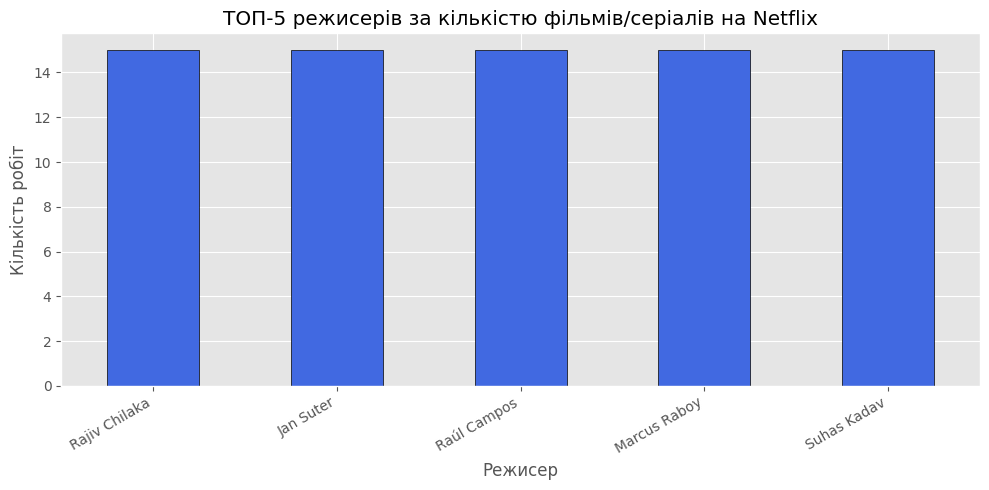


=== ВІДПОВІДЬ ДО ЗАВДАННЯ 2 ===
type
Movie      70
TV Show    30
Name: count, dtype: int64


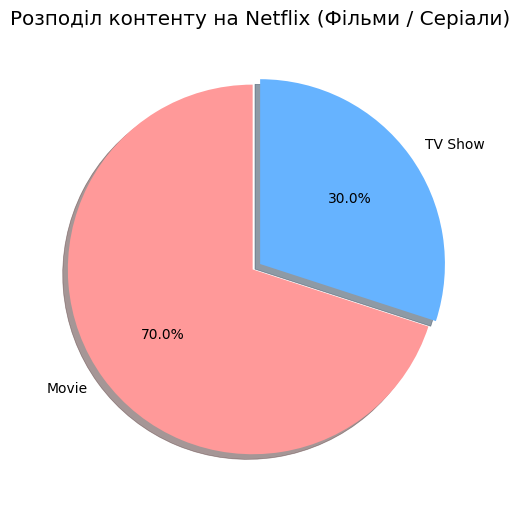


=== ВІДПОВІДЬ ДО ЗАВДАННЯ 3 ===
Країна з найбільшою кількістю ретро-фільмів (до 1960 року): United States (17 фільмів)

=== ВІДПОВІДЬ ДО ЗАВДАННЯ 4 ===
Розподіл релізів за сезонами:
season   Весна  Осінь
type                 
Movie       35     35
TV Show     15     15
-> Контент типу [Movie] частіше додають ВОСЕНИ (Весна: 35 | Осінь: 35)
-> Контент типу [TV Show] частіше додають ВОСЕНИ (Весна: 15 | Осінь: 15)

=== ВІДПОВІДЬ ДО ЗАВДАННЯ 5 ===
Рік, у якому на Netflix було випущено найбільше ФІЛЬМІВ: 2015 (14 фільмів).


In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)


file_path = "netflix_titles.csv"

if not os.path.exists(file_path):
    print(
        f"⚠️ ПОМИЛКА: Файл '{file_path}' не знайдено у сховищі Colab!"
    )
    print(
        "Будь ласка, завантажте файл через ліву панель (іконка папки -> завантажити)."
    )
    print(
        "--- Зараз буде згенеровано тестовий набір даних, щоб код відпрацював для демонстрації ---"
    )


    np.random.seed(42)
    data = {
        "show_id": [f"s{i}" for i in range(1, 101)],
        "type": ["Movie"] * 70 + ["TV Show"] * 30,
        "title": [f"Title {i}" for i in range(1, 101)],
        "director": [
            "Rajiv Chilaka",
            "Jan Suter",
            "Raúl Campos",
            "Marcus Raboy",
            "Suhas Kadav",
        ]
        * 15
        + [np.nan] * 25,
        "country": ["United States"] * 40
        + ["India"] * 20
        + ["United Kingdom"] * 15
        + ["Canada"] * 5
        + [np.nan] * 20,
        "date_added": [
            "September 25, 2021",
            "May 1, 2020",
            "October 15, 2018",
            "March 4, 2017",
        ]
        * 25,
        "release_year": np.random.choice(
            [2020, 2019, 2018, 2015, 1955, 1958, 1945], 100
        ),
        "duration": ["90 min"] * 70 + ["1 Season"] * 30,
    }
    df = pd.DataFrame(data)
else:

    df = pd.read_csv(file_path)
    print("✅ Реальний датасет Netflix успішно завантажено!")


print("\n--- Перші 3 рядки таблиці ---")
display(df.head(3))

print("\n=== ВІДПОВІДЬ ДО ЗАВДАННЯ 1 ===")
directors_df = df.dropna(subset=["director"])
top_directors = directors_df["director"].value_counts().head(5)
print("ТОП-5 режисерів за кількістю контенту:")
print(top_directors)


plt.figure(figsize=(10, 5))
top_directors.plot(kind="bar", color="royalblue", edgecolor="black")
plt.title("ТОП-5 режисерів за кількістю фільмів/серіалів на Netflix")
plt.xlabel("Режисер")
plt.ylabel("Кількість робіт")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


print("\n=== ВІДПОВІДЬ ДО ЗАВДАННЯ 2 ===")
type_counts = df["type"].value_counts()
print(type_counts)


plt.figure(figsize=(6, 6))
type_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["#ff9999", "#66b3ff"],
    explode=(0.05, 0),
    shadow=True,
)
plt.title("Розподіл контенту на Netflix (Фільми / Серіали)")
plt.ylabel("")
plt.show()


print("\n=== ВІДПОВІДЬ ДО ЗАВДАННЯ 3 ===")
old_movies = df[(df["type"] == "Movie") & (df["release_year"] < 1960)]

if not old_movies.empty:
    old_movies_countries = old_movies.dropna(subset=["country"])[
        "country"
    ].value_counts()
    if not old_movies_countries.empty:
        best_old_country = old_movies_countries.idxmax()
        count_old_movies = old_movies_countries.max()
        print(
            f"Країна з найбільшою кількістю ретро-фільмів (до 1960 року): {best_old_country} ({count_old_movies} фільмів)"
        )
    else:
        print("Усі знайдені старі фільми мають пусте значення країни (NaN).")
else:
    print("Фільмів, випущених до 1960 року, в цьому наборі даних немає.")


print("\n=== ВІДПОВІДЬ ДО ЗАВДАННЯ 4 ===")
df_dates = df.dropna(subset=["date_added"]).copy()
df_dates["date_added"] = pd.to_datetime(
    df_dates["date_added"].str.strip(), errors="coerce"
)
df_dates = df_dates.dropna(subset=["date_added"])
df_dates["month"] = df_dates["date_added"].dt.month


def get_season(month):
    if month in [3, 4, 5]:
        return "Весна"
    elif month in [9, 10, 11]:
        return "Осінь"
    else:
        return "Інший сезон"


df_dates["season"] = df_dates["month"].apply(get_season)
season_distribution = (
    df_dates.groupby(["type", "season"]).size().unstack(fill_value=0)
)
print("Розподіл релізів за сезонами:")
print(season_distribution)


for c_type in ["Movie", "TV Show"]:
    if c_type in season_distribution.index:
        spring = (
            season_distribution.loc[c_type, "Весна"]
            if "Весна" in season_distribution.columns
            else 0
        )
        autumn = (
            season_distribution.loc[c_type, "Осінь"]
            if "Осінь" in season_distribution.columns
            else 0
        )
        res_season = "ВЕСНОЮ" if spring > autumn else "ВОСЕНИ"
        print(
            f"-> Контент типу [{c_type}] частіше додають {res_season} (Весна: {spring} | Осінь: {autumn})"
        )


print("\n=== ВІДПОВІДЬ ДО ЗАВДАННЯ 5 ===")
movies_only = df[df["type"] == "Movie"]
best_year_movies = movies_only["release_year"].value_counts()

if not best_year_movies.empty:
    peak_year = best_year_movies.idxmax()
    peak_count = best_year_movies.max()
    print(
        f"Рік, у якому на Netflix було випущено найбільше ФІЛЬМІВ: {peak_year} ({peak_count} фільмів)."
    )
else:
    print("Дані про фільми відсутні.")